In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Imports para modelos y métricas
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                           precision_recall_curve, roc_auc_score, 
                           average_precision_score, recall_score, 
                           precision_score, f1_score, make_scorer)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

🚀 INICIANDO COMPARACIÓN DE MODELOS
📊 Cargando datos...
✅ Datos cargados: (3495160, 16)
📅 Rango temporal: 2017-01-01 00:00:00 - 2024-12-31 23:00:00
⚖️  Distribución de clases: accident
0    3427736
1      67424
Name: count, dtype: int64
📍 Porcentaje de accidentes: 1.93%

📈 Datos de entrenamiento: (3271717, 13)
🧪 Datos de test: (223443, 13)
📊 Split date: 2024-06-30

🎯 Distribución en entrenamiento:
   - Total: 3,271,717
   - Accidentes: 63,645 (1.95%)
   - No accidentes: 3,208,072

🎯 Distribución en test:
   - Total: 223,443
   - Accidentes: 3,779 (1.69%)
   - No accidentes: 219,664

🤖 Configurando modelos base...
⚖️  Pesos de clase calculados: {0: np.float64(0.5099195092878215), 1: np.float64(25.702859611909812)}
✅ Modelos configurados: ['Logistic_Regression', 'Random_Forest', 'XGBoost', 'LightGBM']

🔄 Iniciando validación cruzada temporal...

🔄 Validación cruzada para Logistic_Regression...
   📊 CV Recall: 0.5147 (±0.1618)
   📊 CV Precision: 0.0354 (±0.0012)

🔄 Validación cruzada para 

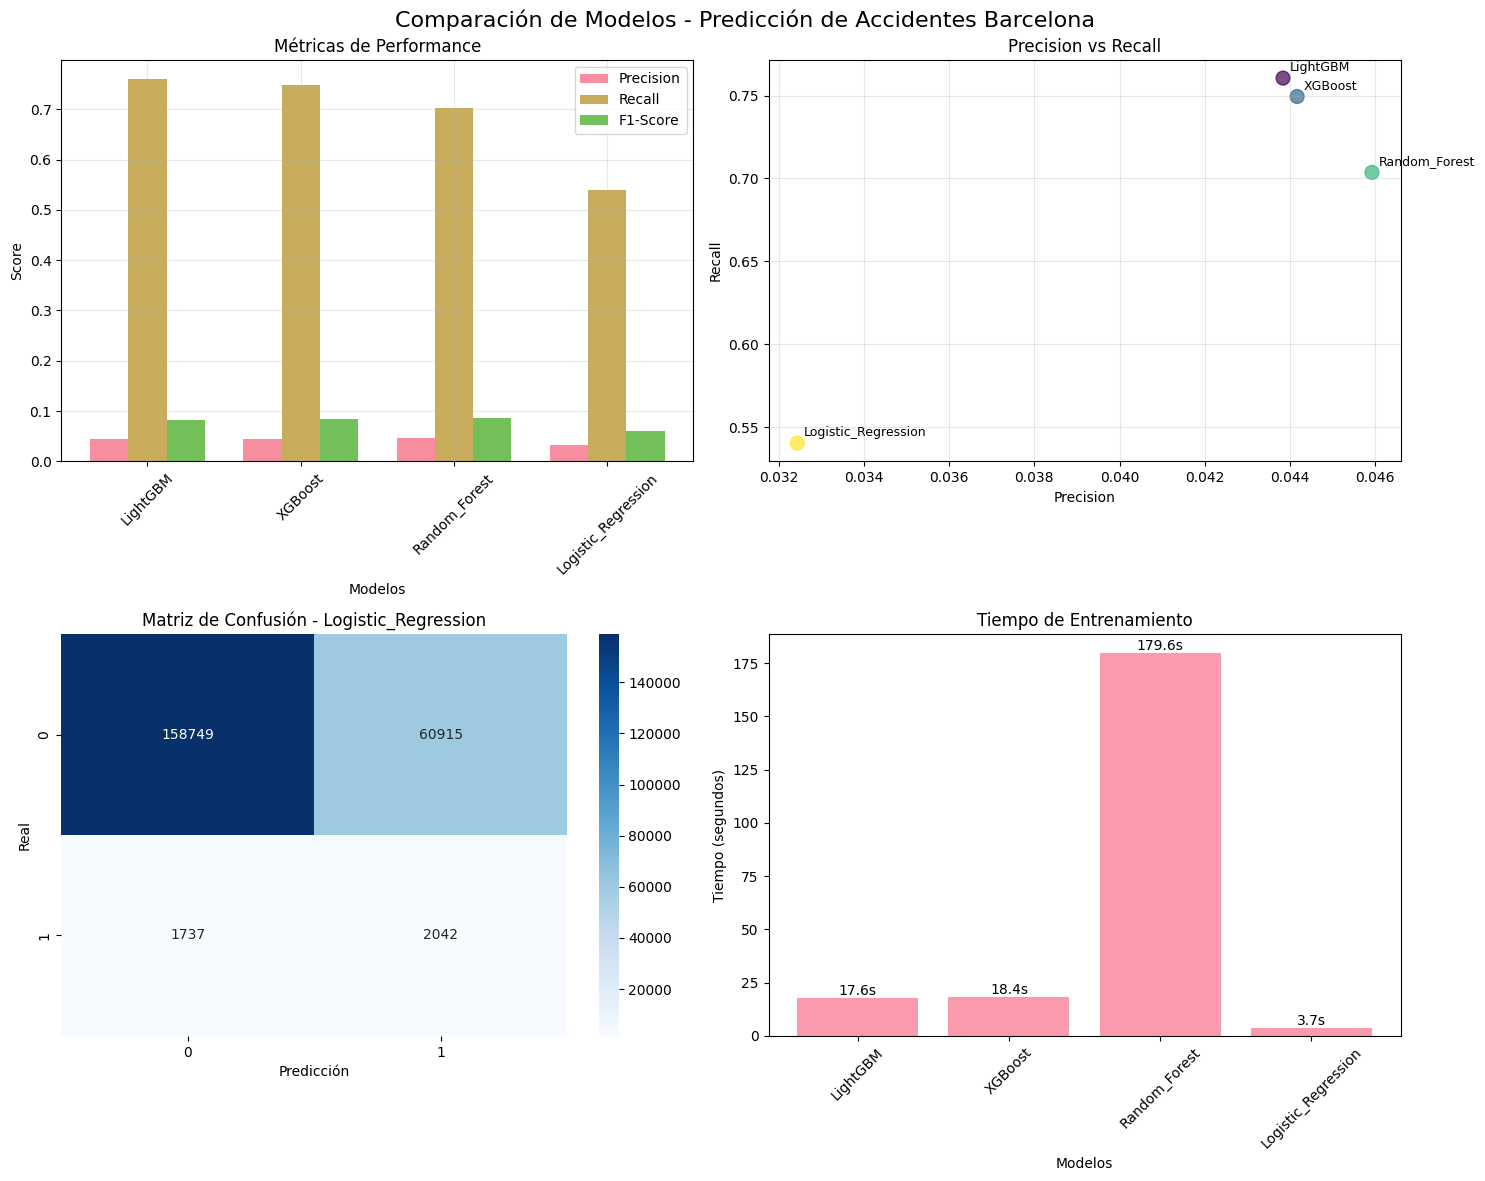


💾 Guardando resultados...
✅ Resultados guardados:
   📊 model_comparison_results.csv
   📄 model_comparison_detailed.txt
   📊 model_comparison_results.png
   🤖 best_model_lightgbm.pkl

🎉 COMPARACIÓN COMPLETADA
🏆 Mejor modelo: LightGBM
📁 Modelo guardado: best_model_lightgbm.pkl

📋 RESUMEN FINAL:
   🏆 Mejor modelo: LightGBM
   💾 Archivo modelo: best_model_lightgbm.pkl
   📊 Usa el archivo 'best_model_lightgbm.pkl' en el script de optimización


In [5]:
#!/usr/bin/env python3
"""
Script 1: Comparación de Modelos Base para Predicción de Accidentes
Dataset: Accidentes Barcelona 2017-2024
Objetivo: Maximizar recall manteniendo precisión aceptable (datos desbalanceados ~2% clase positiva)
"""
# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")

class AccidentModelComparison:
    def __init__(self, data_path):
        """
        Inicializa el comparador de modelos
        
        Parameters:
        data_path (str): Ruta al archivo CSV con los datos
        """
        self.data_path = data_path
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = StandardScaler()
        self.models = {}
        self.results = {}
        
    def load_and_prepare_data(self):
        """Carga y prepara los datos para entrenamiento"""
        print("📊 Cargando datos...")
        self.df = pd.read_csv(self.data_path)
        
        # Convertir time_n a datetime
        self.df['time_n'] = pd.to_datetime(self.df['time_n'])
        
        print(f"✅ Datos cargados: {self.df.shape}")
        print(f"📅 Rango temporal: {self.df['time_n'].min()} - {self.df['time_n'].max()}")
        print(f"⚖️  Distribución de clases: {self.df['accident'].value_counts().sort_index()}")
        print(f"📍 Porcentaje de accidentes: {(self.df['accident'].sum() / len(self.df) * 100):.2f}%")
        
        # Ordenar por tiempo
        self.df = self.df.sort_values('time_n')
        
        # Split temporal - últimos 6 meses para test
        split_date = self.df['time_n'].max() - pd.DateOffset(months=6)
        
        train_mask = self.df['time_n'] < split_date
        test_mask = self.df['time_n'] >= split_date
        
        # Features (excluir time_n y geometry)
        feature_cols = [col for col in self.df.columns 
                       if col not in ['accident', 'time_n', 'geometry']]
        
        self.X_train = self.df[train_mask][feature_cols]
        self.X_test = self.df[test_mask][feature_cols]
        self.y_train = self.df[train_mask]['accident']
        self.y_test = self.df[test_mask]['accident']
        
        print(f"\n📈 Datos de entrenamiento: {self.X_train.shape}")
        print(f"🧪 Datos de test: {self.X_test.shape}")
        print(f"📊 Split date: {split_date.strftime('%Y-%m-%d')}")
        
        # Información de distribución temporal
        print(f"\n🎯 Distribución en entrenamiento:")
        print(f"   - Total: {len(self.y_train):,}")
        print(f"   - Accidentes: {self.y_train.sum():,} ({self.y_train.mean()*100:.2f}%)")
        print(f"   - No accidentes: {(~self.y_train.astype(bool)).sum():,}")
        
        print(f"\n🎯 Distribución en test:")
        print(f"   - Total: {len(self.y_test):,}")
        print(f"   - Accidentes: {self.y_test.sum():,} ({self.y_test.mean()*100:.2f}%)")
        print(f"   - No accidentes: {(~self.y_test.astype(bool)).sum():,}")
        
    def setup_models(self):
        """Configura los modelos base con parámetros optimizados para datos desbalanceados"""
        print("\n🤖 Configurando modelos base...")
        
        # Calcular pesos de clase
        class_weights = compute_class_weight('balanced', 
                                           classes=np.unique(self.y_train), 
                                           y=self.y_train)
        class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
        
        print(f"⚖️  Pesos de clase calculados: {class_weight_dict}")
        
        # 1. Logistic Regression (baseline)
        self.models['Logistic_Regression'] = LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
        
        # 2. Random Forest
        self.models['Random_Forest'] = RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        
        # 3. XGBoost
        scale_pos_weight = (len(self.y_train) - self.y_train.sum()) / self.y_train.sum()
        
        self.models['XGBoost'] = XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss'
        )
        
        # 4. LightGBM
        self.models['LightGBM'] = lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        
        print(f"✅ Modelos configurados: {list(self.models.keys())}")
    
    def evaluate_model(self, model, X_train, X_test, y_train, y_test, model_name):
        """Evalúa un modelo individual"""
        print(f"\n🔄 Entrenando {model_name}...")
        
        # Entrenar
        start_time = datetime.now()
        
        # Escalar datos para Logistic Regression
        if model_name == 'Logistic_Regression':
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        training_time = (datetime.now() - start_time).total_seconds()
        
        # Métricas
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        pr_auc = average_precision_score(y_test, y_pred_proba)
        
        # Matriz de confusión
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # Métricas adicionales
        specificity = tn / (tn + fp)
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        
        results = {
            'model': model,
            'model_name': model_name,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'specificity': specificity,
            'npv': npv,
            'training_time': training_time,
            'confusion_matrix': cm,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'true_positives': tp,
            'false_positives': fp,
            'true_negatives': tn,
            'false_negatives': fn
        }
        
        print(f"✅ {model_name} completado en {training_time:.2f}s")
        print(f"   📊 Recall: {recall:.4f} | Precision: {precision:.4f} | F1: {f1:.4f}")
        
        return results
    
    def cross_validate_models(self):
        """Realiza validación cruzada temporal para todos los modelos"""
        print("\n🔄 Iniciando validación cruzada temporal...")
        
        # TimeSeriesSplit para validación cruzada
        tscv = TimeSeriesSplit(n_splits=3)
        
        # Métricas personalizadas
        scoring = {
            'precision': make_scorer(precision_score, zero_division=0),
            'recall': make_scorer(recall_score, zero_division=0),
            'f1': make_scorer(f1_score, zero_division=0),
            'roc_auc': make_scorer(roc_auc_score, needs_proba=True)
        }
        
        cv_results = {}
        
        for name, model in self.models.items():
            print(f"\n🔄 Validación cruzada para {name}...")
            
            # Preparar datos
            if name == 'Logistic_Regression':
                X_scaled = self.scaler.fit_transform(self.X_train)
                scores = cross_validate(model, X_scaled, self.y_train, 
                                      cv=tscv, scoring=scoring, n_jobs=-1)
            else:
                scores = cross_validate(model, self.X_train, self.y_train, 
                                      cv=tscv, scoring=scoring, n_jobs=-1)
            
            cv_results[name] = {
                'precision_mean': scores['test_precision'].mean(),
                'precision_std': scores['test_precision'].std(),
                'recall_mean': scores['test_recall'].mean(),
                'recall_std': scores['test_recall'].std(),
                'f1_mean': scores['test_f1'].mean(),
                'f1_std': scores['test_f1'].std(),
                'roc_auc_mean': scores['test_roc_auc'].mean(),
                'roc_auc_std': scores['test_roc_auc'].std(),
            }
            
            print(f"   📊 CV Recall: {scores['test_recall'].mean():.4f} (±{scores['test_recall'].std():.4f})")
            print(f"   📊 CV Precision: {scores['test_precision'].mean():.4f} (±{scores['test_precision'].std():.4f})")
        
        return cv_results
    
    def compare_models(self):
        """Compara todos los modelos y muestra resultados"""
        print("\n🏁 Comparando modelos en conjunto de test...")
        
        # Evaluar cada modelo
        for name, model in self.models.items():
            self.results[name] = self.evaluate_model(
                model, self.X_train, self.X_test, self.y_train, self.y_test, name
            )
        
        # Crear DataFrame con resultados
        comparison_data = []
        for name, results in self.results.items():
            comparison_data.append({
                'Modelo': name,
                'Precision': results['precision'],
                'Recall': results['recall'],
                'F1-Score': results['f1_score'],
                'ROC-AUC': results['roc_auc'],
                'PR-AUC': results['pr_auc'],
                'Specificity': results['specificity'],
                'Tiempo (s)': results['training_time'],
                'TP': results['true_positives'],
                'FP': results['false_positives'],
                'TN': results['true_negatives'],
                'FN': results['false_negatives']
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df = comparison_df.sort_values('Recall', ascending=False)
        
        print("\n📊 RESULTADOS COMPARATIVOS:")
        print("=" * 80)
        print(comparison_df.round(4).to_string(index=False))
        
        # Identificar mejor modelo
        # Priorizar recall pero considerar balance con precision
        comparison_df['Score_Balanceado'] = (
            0.6 * comparison_df['Recall'] + 
            0.3 * comparison_df['Precision'] + 
            0.1 * comparison_df['F1-Score']
        )
        
        best_model_name = comparison_df.loc[comparison_df['Score_Balanceado'].idxmax(), 'Modelo']
        
        print(f"\n🏆 MEJOR MODELO: {best_model_name}")
        print(f"   📈 Score balanceado: {comparison_df.loc[comparison_df['Modelo'] == best_model_name, 'Score_Balanceado'].iloc[0]:.4f}")
        
        return comparison_df, best_model_name
    
    def plot_results(self, comparison_df):
        """Genera visualizaciones de los resultados"""
        print("\n📊 Generando visualizaciones...")
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Comparación de Modelos - Predicción de Accidentes Barcelona', fontsize=16)
        
        # 1. Gráfico de barras - Métricas principales
        ax1 = axes[0, 0]
        metrics = ['Precision', 'Recall', 'F1-Score']
        x = np.arange(len(comparison_df))
        width = 0.25
        
        for i, metric in enumerate(metrics):
            ax1.bar(x + i*width, comparison_df[metric], width, label=metric, alpha=0.8)
        
        ax1.set_xlabel('Modelos')
        ax1.set_ylabel('Score')
        ax1.set_title('Métricas de Performance')
        ax1.set_xticks(x + width)
        ax1.set_xticklabels(comparison_df['Modelo'], rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Scatter plot Precision vs Recall
        ax2 = axes[0, 1]
        scatter = ax2.scatter(comparison_df['Precision'], comparison_df['Recall'], 
                            s=100, alpha=0.7, c=range(len(comparison_df)), cmap='viridis')
        
        for i, model in enumerate(comparison_df['Modelo']):
            ax2.annotate(model, (comparison_df.iloc[i]['Precision'], comparison_df.iloc[i]['Recall']),
                        xytext=(5, 5), textcoords='offset points', fontsize=9)
        
        ax2.set_xlabel('Precision')
        ax2.set_ylabel('Recall')
        ax2.set_title('Precision vs Recall')
        ax2.grid(True, alpha=0.3)
        
        # 3. Matriz de confusión del mejor modelo
        best_idx = comparison_df['Score_Balanceado'].idxmax()
        best_model_name = comparison_df.iloc[best_idx]['Modelo']
        cm = self.results[best_model_name]['confusion_matrix']
        
        ax3 = axes[1, 0]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
        ax3.set_title(f'Matriz de Confusión - {best_model_name}')
        ax3.set_xlabel('Predicción')
        ax3.set_ylabel('Real')
        
        # 4. Tiempo de entrenamiento
        ax4 = axes[1, 1]
        bars = ax4.bar(comparison_df['Modelo'], comparison_df['Tiempo (s)'], alpha=0.7)
        ax4.set_xlabel('Modelos')
        ax4.set_ylabel('Tiempo (segundos)')
        ax4.set_title('Tiempo de Entrenamiento')
        plt.setp(ax4.get_xticklabels(), rotation=45)
        
        # Añadir valores en las barras
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}s', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig('model_comparison_results.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def save_results(self, comparison_df, best_model_name, cv_results):
        """Guarda los resultados y el mejor modelo"""
        print(f"\n💾 Guardando resultados...")
        
        # Guardar CSV con comparación
        comparison_df.to_csv('model_comparison_results.csv', index=False)
        
        # Guardar resultados detallados
        with open('model_comparison_detailed.txt', 'w') as f:
            f.write("COMPARACIÓN DE MODELOS - PREDICCIÓN ACCIDENTES BARCELONA\n")
            f.write("=" * 60 + "\n\n")
            
            f.write(f"Dataset: {self.data_path}\n")
            f.write(f"Registros totales: {len(self.df):,}\n")
            f.write(f"Período: {self.df['time_n'].min()} - {self.df['time_n'].max()}\n")
            f.write(f"Porcentaje accidentes: {(self.df['accident'].mean() * 100):.2f}%\n\n")
            
            f.write("MEJORES RESULTADOS:\n")
            f.write("-" * 30 + "\n")
            f.write(comparison_df.to_string(index=False))
            f.write(f"\n\nMEJOR MODELO: {best_model_name}\n")
            
            # Validación cruzada
            f.write(f"\n\nRESULTADOS VALIDACIÓN CRUZADA:\n")
            f.write("-" * 40 + "\n")
            for model, scores in cv_results.items():
                f.write(f"\n{model}:\n")
                f.write(f"  Recall: {scores['recall_mean']:.4f} (±{scores['recall_std']:.4f})\n")
                f.write(f"  Precision: {scores['precision_mean']:.4f} (±{scores['precision_std']:.4f})\n")
                f.write(f"  F1: {scores['f1_mean']:.4f} (±{scores['f1_std']:.4f})\n")
                f.write(f"  ROC-AUC: {scores['roc_auc_mean']:.4f} (±{scores['roc_auc_std']:.4f})\n")
        
        # Guardar mejor modelo
        import joblib
        best_model = self.results[best_model_name]['model']
        model_filename = f'best_model_{best_model_name.lower()}.pkl'
        joblib.dump(best_model, model_filename)
        
        # Si es logistic regression, guardar también el scaler
        if best_model_name == 'Logistic_Regression':
            joblib.dump(self.scaler, 'scaler.pkl')
        
        print(f"✅ Resultados guardados:")
        print(f"   📊 model_comparison_results.csv")
        print(f"   📄 model_comparison_detailed.txt")
        print(f"   📊 model_comparison_results.png")
        print(f"   🤖 {model_filename}")
        
        return best_model_name, model_filename
    
    def run_comparison(self):
        """Ejecuta la comparación completa"""
        print("🚀 INICIANDO COMPARACIÓN DE MODELOS")
        print("=" * 50)
        
        # Cargar datos
        self.load_and_prepare_data()
        
        # Configurar modelos
        self.setup_models()
        
        # Validación cruzada
        cv_results = self.cross_validate_models()
        
        # Comparar modelos
        comparison_df, best_model_name = self.compare_models()
        
        # Generar visualizaciones
        self.plot_results(comparison_df)
        
        # Guardar resultados
        best_model_name, model_filename = self.save_results(comparison_df, best_model_name, cv_results)
        
        print(f"\n🎉 COMPARACIÓN COMPLETADA")
        print(f"🏆 Mejor modelo: {best_model_name}")
        print(f"📁 Modelo guardado: {model_filename}")
        
        return best_model_name, model_filename, comparison_df

def main():
    """Función principal"""
    # Configuración
    DATA_PATH = "../data/processed/df_ready_model.csv"
    
    # Crear instancia y ejecutar
    comparator = AccidentModelComparison(DATA_PATH)
    best_model, model_file, results_df = comparator.run_comparison()
    
    print(f"\n📋 RESUMEN FINAL:")
    print(f"   🏆 Mejor modelo: {best_model}")
    print(f"   💾 Archivo modelo: {model_file}")
    print(f"   📊 Usa el archivo '{model_file}' en el script de optimización")

if __name__ == "__main__":
    main()